In [3]:
print ('welcome')

welcome


In [4]:
%pip install pandas numpy seaborn matplotlib scikit-learn xgboost shap


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import xgboost
import shap

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)


c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pandas: 3.0.6
NumPy: 2.4.3
Scikit-learn: 1.9.1
XGBoost: 3.4.1
SHAP: 0.52.0


In [6]:
df = pd.read_csv("data/Maternal Health Risk Data Set.csv")

df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [7]:
print("Dataset shape:", df.shape)

Dataset shape: (1014, 7)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB


In [9]:
df["RiskLevel"].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [10]:
df.describe(
  
)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [11]:
df[df["HeartRate"] < 40]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk


In [12]:
df[df["HeartRate"] < 40]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk


In [13]:
df[df.duplicated(keep=False)]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
1,35,140,90,13.00,98.0,70,high risk
2,29,90,70,8.00,100.0,80,high risk
3,30,140,85,7.00,98.0,70,high risk
4,35,120,60,6.10,98.0,76,low risk
5,23,140,80,7.01,98.0,70,high risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.00,98.0,80,high risk
1010,55,120,90,18.00,98.0,60,high risk
1011,35,85,60,19.00,98.0,86,high risk
1012,43,120,90,18.00,98.0,70,high risk


In [14]:
#Number of completely duplicated rows excluding the first occurance
df.duplicated().sum()

np.int64(562)

In [15]:
dup_counts = df.value_counts()

dup_counts.head(20)

Age  SystolicBP  DiastolicBP  BS    BodyTemp  HeartRate  RiskLevel
19   120         80           7.0   98.0      70         mid risk     27
48   120         80           11.0  98.0      88         high risk    14
31   120         60           6.1   98.0      76         mid risk     13
40   160         100          19.0  98.0      77         high risk    10
55   140         95           19.0  98.0      77         high risk    10
32   140         90           18.0  98.0      88         high risk     9
54   140         100          15.0  98.0      66         high risk     9
32   120         90           7.5   98.0      70         low risk      7
42   120         80           7.5   98.0      70         low risk      7
40   120         95           11.0  98.0      80         high risk     7
31   120         60           6.1   98.0      76         low risk      7
19   120         80           7.0   98.0      70         low risk      7
48   120         80           11.0  98.0      88         

In [16]:
print("Heart rate < 40:")
display(df[df["HeartRate"] < 40])

print("\nAge < 18:")
display(df[df["Age"] < 18])

print("\nBlood sugar values:")
print(df["BS"].describe())

print("\nBody temperature values:")
print(df["BodyTemp"].value_counts().sort_index())

Heart rate < 40:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk



Age < 18:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
15,15,120,80,7.01,98.0,70,low risk
19,10,70,50,6.90,98.0,70,low risk
25,16,100,70,7.20,98.0,80,low risk
35,12,95,60,6.10,102.0,60,low risk
48,15,76,49,7.50,98.0,77,low risk
...,...,...,...,...,...,...,...
996,12,90,60,8.00,102.0,66,high risk
1000,12,90,60,11.00,102.0,60,high risk
1004,13,90,65,9.00,101.0,80,high risk
1005,17,90,65,7.70,103.0,67,high risk



Blood sugar values:
count    1014.000000
mean        8.725986
std         3.293532
min         6.000000
25%         6.900000
50%         7.500000
75%         8.000000
max        19.000000
Name: BS, dtype: float64

Body temperature values:
BodyTemp
98.0     804
98.4       2
98.6       1
99.0      10
100.0     20
101.0     98
102.0     66
103.0     13
Name: count, dtype: int64


In [17]:
df["BS"].describe()

count    1014.000000
mean        8.725986
std         3.293532
min         6.000000
25%         6.900000
50%         7.500000
75%         8.000000
max        19.000000
Name: BS, dtype: float64

In [18]:
df.groupby("RiskLevel")[[
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]].mean()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
high risk,36.216912,124.194853,85.073529,12.122610,98.899265,76.742647
low risk,26.869458,105.866995,72.534483,7.220271,98.368966,72.770936
mid risk,28.363095,113.154762,74.232143,7.795744,98.833333,74.175595


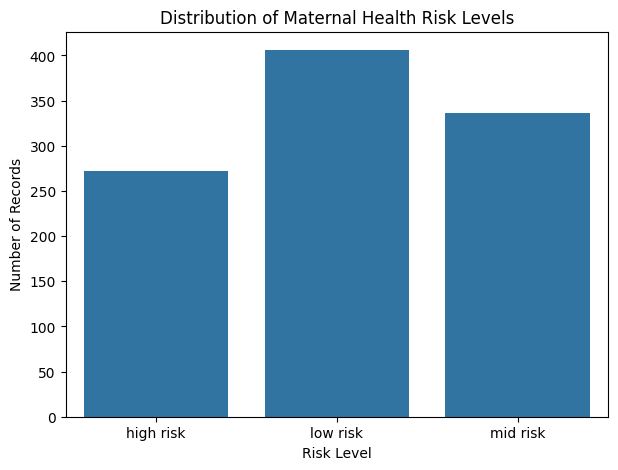

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="RiskLevel")

plt.title("Distribution of Maternal Health Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")

plt.show()

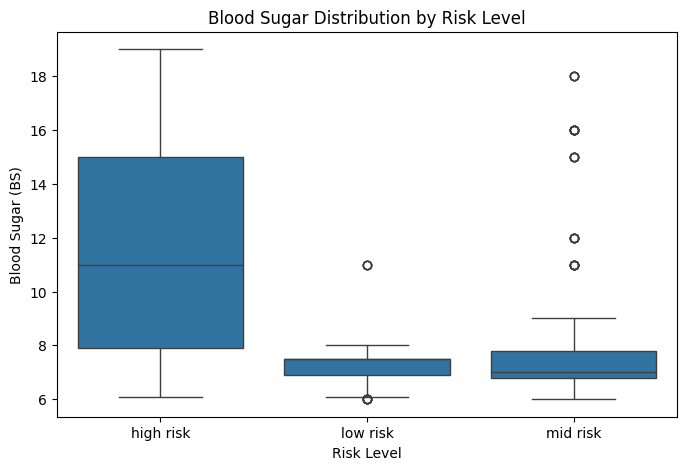

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="RiskLevel", y="BS")

plt.title("Blood Sugar Distribution by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Blood Sugar (BS)")

plt.show()

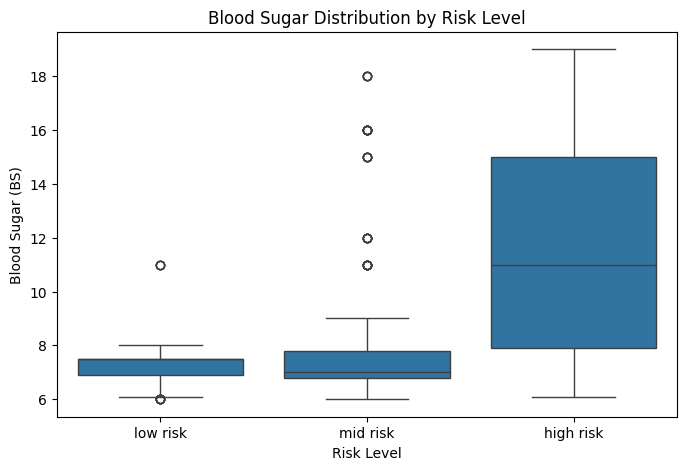

In [21]:
risk_order = ["low risk", "mid risk", "high risk"]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="RiskLevel",
    y="BS",
    order=risk_order
)

plt.title("Blood Sugar Distribution by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Blood Sugar (BS)")

plt.show()

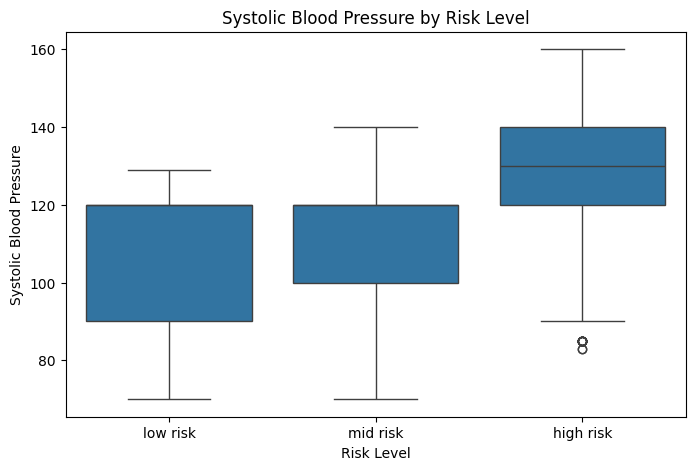

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="RiskLevel",
    y="SystolicBP",
    order=risk_order
)

plt.title("Systolic Blood Pressure by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Systolic Blood Pressure")

plt.show()

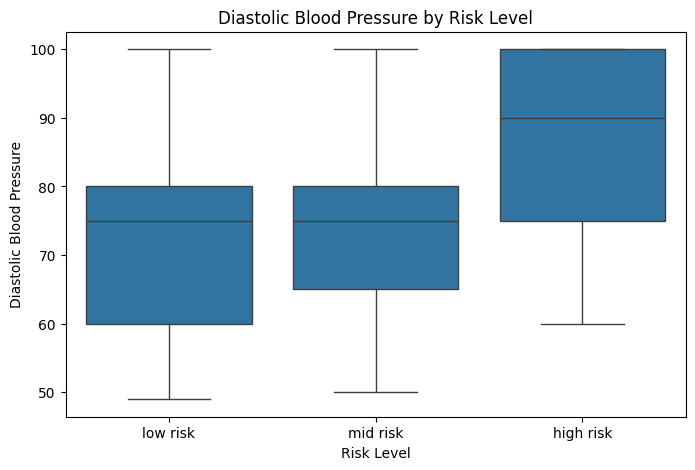

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="RiskLevel",
    y="DiastolicBP",
    order=risk_order
)

plt.title("Diastolic Blood Pressure by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Diastolic Blood Pressure")

plt.show()


In [24]:
print(df.shape)


(1014, 7)


In [25]:
print(risk_order)


['low risk', 'mid risk', 'high risk']


In [26]:
risk_order = ["low risk", "mid risk", "high risk"]

In [27]:
print(risk_order)

['low risk', 'mid risk', 'high risk']


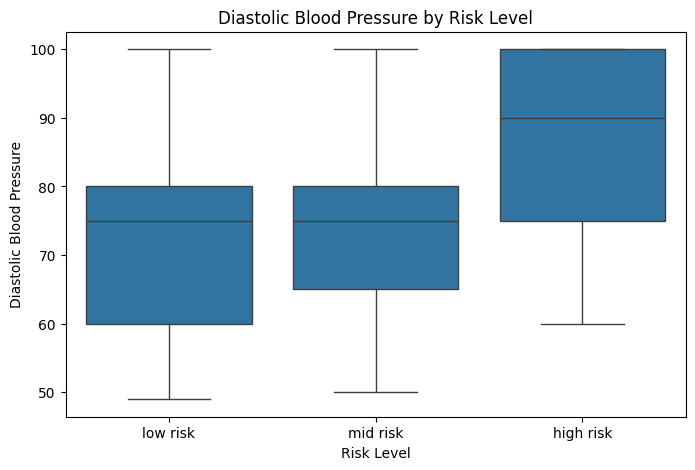

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="RiskLevel",
    y="DiastolicBP",
    order=risk_order
)

plt.title("Diastolic Blood Pressure by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Diastolic Blood Pressure")

plt.show()


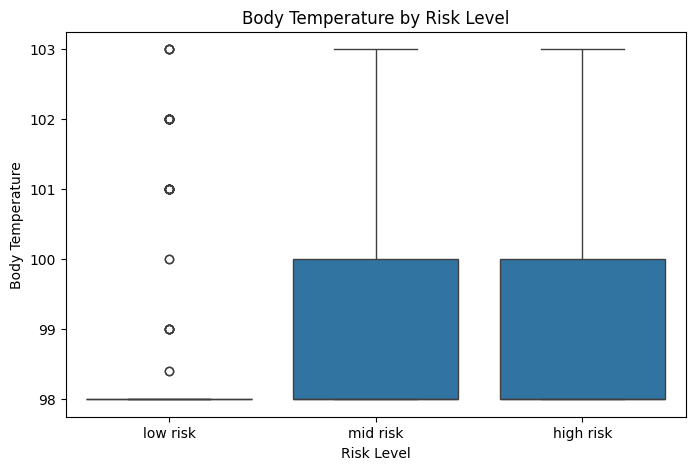

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="RiskLevel",
    y="BodyTemp",
    order=risk_order
)

plt.title("Body Temperature by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Body Temperature")

plt.show()

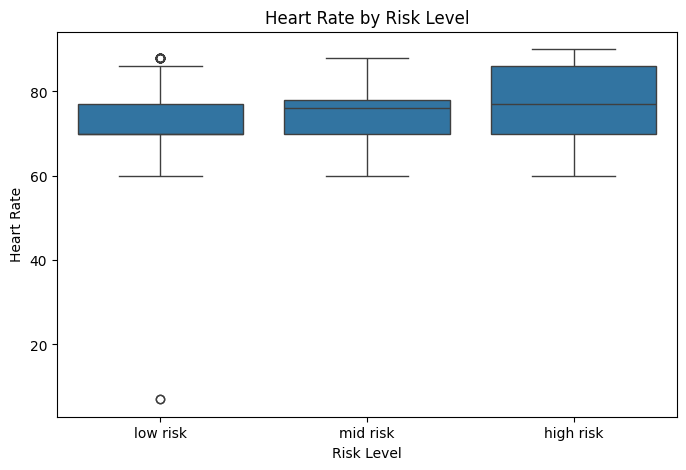

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="RiskLevel",
    y="HeartRate",
    order=risk_order
)

plt.title("Heart Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Heart Rate")

plt.show()

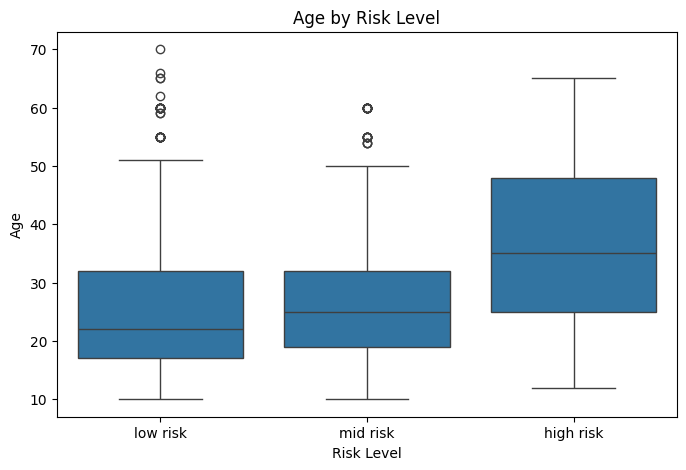

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="RiskLevel",
    y="Age",
    order=risk_order
)

plt.title("Age by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Age")

plt.show()

In [32]:
numeric_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
Age,1.000000,0.416045,0.398026,0.473284,-0.255323,0.079798
SystolicBP,0.416045,1.000000,0.787006,0.425172,-0.286616,-0.023108
DiastolicBP,0.398026,0.787006,1.000000,0.423824,-0.257538,-0.046151
BS,0.473284,0.425172,0.423824,1.000000,-0.103493,0.142867
BodyTemp,-0.255323,-0.286616,-0.257538,-0.103493,1.000000,0.098771
HeartRate,0.079798,-0.023108,-0.046151,0.142867,0.098771,1.000000


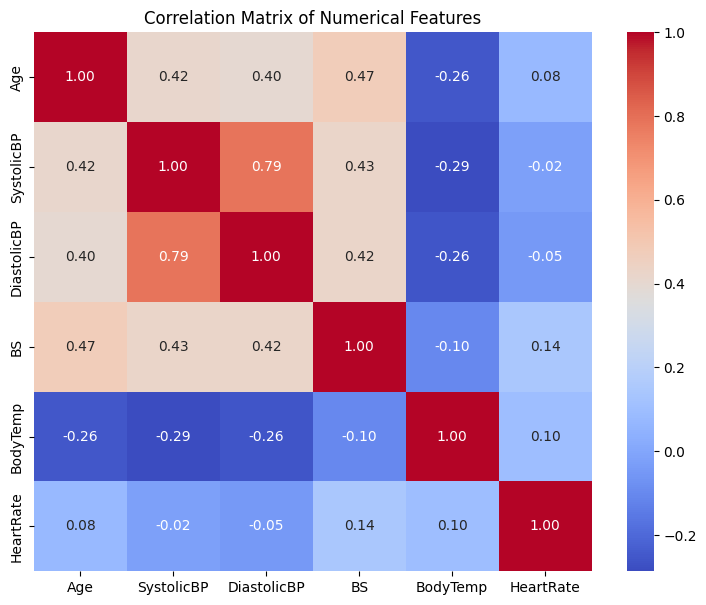

In [33]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [34]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 562


In [35]:
df[df.duplicated(keep=False)].sort_values(
    by=["Age", "SystolicBP", "DiastolicBP"]
).head(20)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
670,10,100,50,6.0,99.0,70,mid risk
849,10,100,50,6.0,99.0,70,mid risk
171,12,90,60,7.9,102.0,66,high risk
267,12,90,60,8.0,102.0,66,high risk
276,12,90,60,11.0,102.0,60,high risk
543,12,90,60,7.5,102.0,66,low risk
552,12,90,60,7.5,102.0,60,low risk
588,12,90,60,7.5,102.0,66,mid risk
827,12,90,60,7.5,102.0,66,mid risk
934,12,90,60,7.5,102.0,66,low risk


In [36]:
print("Total rows:", len(df))
print("Unique rows:", df.drop_duplicates().shape[0])
print("Duplicate rows:", df.duplicated().sum())

Total rows: 1014
Unique rows: 452
Duplicate rows: 562


## Data Quality Summary

The dataset contains 1,014 records and 7 variables. No missing values were identified during the initial data-quality checks. However, 562 records are exact duplicates, leaving 452 unique records.

The target variable, RiskLevel, contains three ordered categories: Low Risk, Mid Risk, and High Risk. Therefore, RiskLevel is treated as an ordinal categorical target rather than a nominal categorical variable.

Potentially unusual values identified during EDA will be considered before the preprocessing stage. The original dataset will be preserved, and any data-cleaning decisions will be applied only to a separate modelling dataset.

In [37]:
# Check the distribution of risk levels in the dataset
df["RiskLevel"].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [38]:
# Check duplicate records by risk level
duplicates = df[df.duplicated(keep=False)]

duplicates["RiskLevel"].value_counts()

RiskLevel
mid risk     336
low risk     292
high risk    238
Name: count, dtype: int64

In [39]:
# Check how frequently duplicate records occur
duplicate_counts = df.value_counts()

duplicate_counts.value_counts().sort_index()

count
1     148
2     198
3      54
4      24
5      11
6       5
7       5
9       2
10      2
13      1
14      1
27      1
Name: count, dtype: int64

In [40]:
# Check whether identical predictor values have different risk labels

features = df.drop(columns=["RiskLevel"])

label_consistency = (
    df.groupby(list(features.columns))["RiskLevel"]
      .nunique()
)

label_consistency.value_counts()

RiskLevel
1    381
2     34
3      1
Name: count, dtype: int64

In [41]:
# Find predictor profiles that have more than one RiskLevel
inconsistent_profiles = (
    df.groupby(list(features.columns))["RiskLevel"]
      .nunique()
)

inconsistent_profiles = inconsistent_profiles[
    inconsistent_profiles > 1
]

inconsistent_profiles

Age  SystolicBP  DiastolicBP  BS    BodyTemp  HeartRate
12   90          60           7.5   102.0     66           2
     95          60           6.9   98.0      65           2
13   90          65           7.5   101.0     80           2
15   120         80           7.5   98.0      70           2
16   100         70           6.9   98.0      80           2
17   85          60           9.0   102.0     86           2
     90          65           7.5   103.0     67           2
18   90          60           6.9   98.0      70           2
19   120         75           6.9   98.0      66           2
                 80           7.0   98.0      70           2
20   100         90           7.5   98.0      88           2
21   90          65           6.9   98.0      76           2
     120         80           6.9   98.0      76           2
                              7.5   98.0      77           2
22   90          60           6.8   98.0      77           2
     100         65          

In [42]:
# Count how many predictor profiles have 2 or 3 different risk labels

inconsistent_summary = inconsistent_profiles.value_counts().sort_index()

print("Predictor profiles with 2 different RiskLevels:",
      inconsistent_summary.get(2, 0))

print("Predictor profiles with 3 different RiskLevels:",
      inconsistent_summary.get(3, 0))

Predictor profiles with 2 different RiskLevels: 34
Predictor profiles with 3 different RiskLevels: 1


In [43]:
# Identify rows belonging to inconsistent predictor profiles

inconsistent_rows = df.merge(
    inconsistent_profiles.reset_index()[features.columns],
    on=list(features.columns),
    how="inner"
)

print("Rows affected by inconsistent labels:", len(inconsistent_rows))

Rows affected by inconsistent labels: 215


In [44]:
# Examine the risk-level distribution among rows with inconsistent labels

inconsistent_rows["RiskLevel"].value_counts()

RiskLevel
mid risk     115
low risk      61
high risk     39
Name: count, dtype: int64

In [45]:
# Check class distribution after removing exact duplicate rows
df_unique = df.drop_duplicates()

print("Rows after removing exact duplicates:", len(df_unique))
print("\nRiskLevel distribution:")
print(df_unique["RiskLevel"].value_counts())

Rows after removing exact duplicates: 452

RiskLevel distribution:
RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64


In [46]:
# Examine the risk-level distribution of repeated records
repeated_rows = df[df.duplicated(keep=False)]

print("Repeated rows:", len(repeated_rows))
print("\nRiskLevel distribution among repeated rows:")
print(repeated_rows["RiskLevel"].value_counts())

Repeated rows: 866

RiskLevel distribution among repeated rows:
RiskLevel
mid risk     336
low risk     292
high risk    238
Name: count, dtype: int64


In [47]:
# Check inconsistent labels after removing exact duplicates

inconsistent_unique = (
    df_unique.groupby(list(features.columns))["RiskLevel"]
    .nunique()
)

inconsistent_unique = inconsistent_unique[
    inconsistent_unique > 1
]

print("Unique predictor profiles with inconsistent labels:",
      len(inconsistent_unique))

Unique predictor profiles with inconsistent labels: 35


In [48]:
inconsistent_unique_rows = df_unique.merge(
    inconsistent_unique.reset_index()[features.columns],
    on=list(features.columns),
    how="inner"
)

print("Unique rows affected by inconsistent labels:", len(inconsistent_unique_rows))

print("\nRiskLevel distribution:")
print(inconsistent_unique_rows["RiskLevel"].value_counts())

Unique rows affected by inconsistent labels: 71

RiskLevel distribution:
RiskLevel
low risk     30
mid risk     30
high risk    11
Name: count, dtype: int64


In [49]:
print("Number of labels per inconsistent predictor profile:")
print(inconsistent_unique.value_counts())

Number of labels per inconsistent predictor profile:
RiskLevel
2    34
3     1
Name: count, dtype: int64


In [50]:
inconsistent_pairs = (
    inconsistent_unique_rows
    .groupby(list(features.columns))["RiskLevel"]
    .agg(lambda x: sorted(x.unique()))
)

print(inconsistent_pairs.value_counts())

RiskLevel
[low risk, mid risk]               24
[high risk, low risk]               5
[high risk, mid risk]               5
[high risk, low risk, mid risk]     1
Name: count, dtype: int64


In [51]:
print(inconsistent_unique_rows[features.columns].describe().round(2))

         Age  SystolicBP  DiastolicBP     BS  BodyTemp  HeartRate
count  71.00       71.00        71.00  71.00     71.00      71.00
mean   28.96      109.86        77.04   8.22     98.45      74.90
std    13.94       13.94        12.67   2.74      1.30       7.53
min    12.00       85.00        60.00   6.10     98.00      60.00
25%    19.00       97.50        65.00   6.90     98.00      70.00
50%    23.00      120.00        80.00   7.50     98.00      76.00
75%    40.00      120.00        87.50   7.50     98.00      80.00
max    60.00      130.00       100.00  18.00    103.00      88.00


In [52]:
print("Inconsistent rows with Age < 18:",
      (inconsistent_unique_rows["Age"] < 18).sum())

print("Inconsistent rows with HeartRate = 7:",
      (inconsistent_unique_rows["HeartRate"] == 7).sum())

Inconsistent rows with Age < 18: 14
Inconsistent rows with HeartRate = 7: 0


In [53]:
inconsistent_adult_rows = inconsistent_unique_rows[
    inconsistent_unique_rows["Age"] >= 18
]

print("Inconsistent rows with Age >= 18:",
      len(inconsistent_adult_rows))

print("\nRiskLevel distribution:")
print(inconsistent_adult_rows["RiskLevel"].value_counts())

Inconsistent rows with Age >= 18: 57

RiskLevel distribution:
RiskLevel
low risk     24
mid risk     24
high risk     9
Name: count, dtype: int64


In [54]:
consistent_profiles = inconsistent_unique.index

print("Consistent predictor profiles:", 452 - len(inconsistent_unique))

Consistent predictor profiles: 417


In [55]:
consistent_rows = df_unique.merge(
    inconsistent_unique.reset_index()[features.columns],
    on=list(features.columns),
    how="left",
    indicator=True
)

consistent_rows = consistent_rows[
    consistent_rows["_merge"] == "left_only"
].drop(columns=["_merge"])

print("Consistent modelling rows:", len(consistent_rows))

print("\nRiskLevel distribution:")
print(consistent_rows["RiskLevel"].value_counts())

print("\nRiskLevel percentages:")
print(
    (consistent_rows["RiskLevel"].value_counts(normalize=True) * 100)
    .round(1)
)

Consistent modelling rows: 381

RiskLevel distribution:
RiskLevel
low risk     204
high risk    101
mid risk      76
Name: count, dtype: int64

RiskLevel percentages:
RiskLevel
low risk     53.5
high risk    26.5
mid risk     19.9
Name: proportion, dtype: float64


In [56]:
df_model = consistent_rows.copy()

print("Final modelling dataset shape:", df_model.shape)
print("\nRiskLevel distribution:")
print(df_model["RiskLevel"].value_counts())

Final modelling dataset shape: (381, 7)

RiskLevel distribution:
RiskLevel
low risk     204
high risk    101
mid risk      76
Name: count, dtype: int64


## Data Quality and Cleaning Summary

The original dataset contained 1,014 records and 7 variables. Initial data-quality checks found no missing values, but a substantial number of exact duplicate records were present. Removing exact duplicates reduced the dataset to 452 unique records.

Further investigation identified 35 predictor profiles where the same combination of Age, SystolicBP, DiastolicBP, BS, BodyTemp and HeartRate was associated with more than one RiskLevel. Of these profiles, 34 had two different risk labels and one had all three risk labels. In total, 71 unique records were associated with these inconsistent predictor profiles.

Because the correct RiskLevel could not be determined reliably from the available data, these ambiguous profiles were excluded rather than assigning or modifying their labels. This avoids introducing an unsupported assumption into the target variable.

The resulting modelling dataset, `df_model`, contains 381 records with consistent predictor–target relationships.

The final RiskLevel distribution is:

* Low risk: 204 (53.5%)
* Mid risk: 76 (19.9%)
* High risk: 101 (26.5%)

The original dataset has been retained unchanged, while `df_model` is used as the cleaned dataset for subsequent modelling and preprocessing.


In [57]:
print("Records with Age < 18:", (df_model["Age"] < 18).sum())

print("\nRiskLevel distribution:")
print(df_model.loc[df_model["Age"] < 18, "RiskLevel"].value_counts())

Records with Age < 18: 82

RiskLevel distribution:
RiskLevel
low risk     50
high risk    19
mid risk     13
Name: count, dtype: int64


In [58]:
print(
    df_model.loc[df_model["Age"] < 18, "Age"]
    .value_counts()
    .sort_index()
)

Age
10     3
12    17
13     3
14     1
15    29
16     5
17    24
Name: count, dtype: int64


In [59]:
print(df_model["Age"].describe())

print("\nAge frequencies:")
print(df_model["Age"].value_counts().sort_index())

count    381.000000
mean      29.238845
std       13.753015
min       10.000000
25%       19.000000
50%       25.000000
75%       35.000000
max       70.000000
Name: Age, dtype: float64

Age frequencies:
Age
10     3
12    17
13     3
14     1
15    29
16     5
17    24
18     8
19    16
20     8
21    16
22    20
23    30
24     1
25    24
26     1
27     4
28     9
29    14
30    13
31     1
32    15
33     2
34     3
35    24
36     2
37     1
38     1
39     2
40     8
41     1
42     8
43     3
44     1
45     6
46     1
48     1
49     3
50    13
51     1
54     2
55    15
56     1
59     1
60    12
62     1
63     1
65     3
66     1
70     1
Name: count, dtype: int64


In [60]:
young_records = df_model[df_model["Age"] <= 14]

print("Records with Age <= 14:", len(young_records))

print("\nRiskLevel distribution:")
print(young_records["RiskLevel"].value_counts())

print("\nRecords:")
print(young_records[["Age", "SystolicBP", "DiastolicBP", "BS",
                     "BodyTemp", "HeartRate", "RiskLevel"]].sort_values("Age"))

Records with Age <= 14: 24

RiskLevel distribution:
RiskLevel
low risk     11
mid risk      7
high risk     6
Name: count, dtype: int64

Records:
     Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
19    10          70           50   6.9      98.0         70   low risk
175   10          85           65   6.9      98.0         70   low risk
444   10         100           50   6.0      99.0         70   mid risk
62    12          95           60   7.2      98.0         77   low risk
148   12          90           60   7.9     102.0         66  high risk
142   12          95           60   7.5      98.0         65   low risk
190   12          90           60   8.0     102.0         66  high risk
35    12          95           60   6.1     102.0         60   low risk
251   12          95           60   6.9      98.0         77   low risk
235   12         120           80   6.9      98.0         80   low risk
197   12          90           60  11.0     102.0         60  

In [61]:
heart_rate_7 = df_model[df_model["HeartRate"] == 7]

print("Records with HeartRate = 7:", len(heart_rate_7))

print("\nRecords:")
print(heart_rate_7)

Records with HeartRate = 7: 1

Records:
     Age  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate RiskLevel
342   16         120           75  7.9      98.0          7  low risk


In [62]:
print("Occurrences of this exact record in original df:")
print(
    df[
        (df["Age"] == 16) &
        (df["SystolicBP"] == 120) &
        (df["DiastolicBP"] == 75) &
        (df["BS"] == 7.9) &
        (df["BodyTemp"] == 98.0) &
        (df["HeartRate"] == 7) &
        (df["RiskLevel"] == "low risk")
    ].shape[0]
)

Occurrences of this exact record in original df:
2


In [63]:
df_final = df_model[df_model["HeartRate"] != 7].copy()

print("Final modelling dataset shape:", df_final.shape)

print("\nHeartRate = 7 records:")
print((df_final["HeartRate"] == 7).sum())

print("\nRiskLevel distribution:")
print(df_final["RiskLevel"].value_counts())

Final modelling dataset shape: (380, 7)

HeartRate = 7 records:
0

RiskLevel distribution:
RiskLevel
low risk     203
high risk    101
mid risk      76
Name: count, dtype: int64


## Final Data Cleaning Summary

The original dataset contained 1,014 records. Data-quality investigation identified substantial exact duplication and inconsistent target labels.

Exact duplicate records were removed, resulting in 452 unique records. Further investigation identified 35 predictor profiles where identical predictor values were associated with different RiskLevel labels. Because the correct label could not be determined reliably, the 71 records belonging to these ambiguous profiles were excluded rather than assigning labels arbitrarily.

One remaining record had an implausible HeartRate value of 7 beats per minute. This record was excluded from the modelling dataset. The original dataset was retained unchanged throughout the cleaning process.

Records with Age below 18 were retained because they are present in the source dataset with valid RiskLevel labels and represent all three risk categories. Their presence will be treated as a characteristic and limitation of the dataset rather than being removed solely because of age.

The resulting `df_final` dataset contains 380 records and 7 variables with no missing values.

The final RiskLevel distribution is:

* Low risk: 203 (53.4%)
* Mid risk: 76 (20.0%)
* High risk: 101 (26.6%)
